계단 함수 - 가장 기본적인 활성화 함수

In [1]:
def step_function(x):
    y = (x>0) #x성분중0보다큰원소들의리스트
    return y.astype(int)

넘파이 타입 자료형 변환 시에는 astype()

In [2]:
import numpy as np
x = np.array([1,-1,0])
print(step_function(x))

[1 0 0]


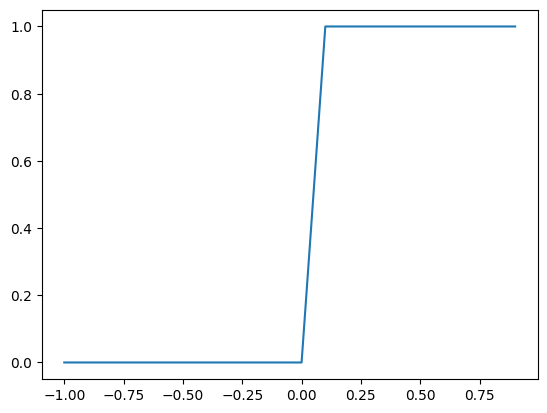

In [3]:
import matplotlib.pyplot as plt
x = np.arange(-1,1,0.1)
y = step_function(x)
plt.plot(x,y)
plt.show()

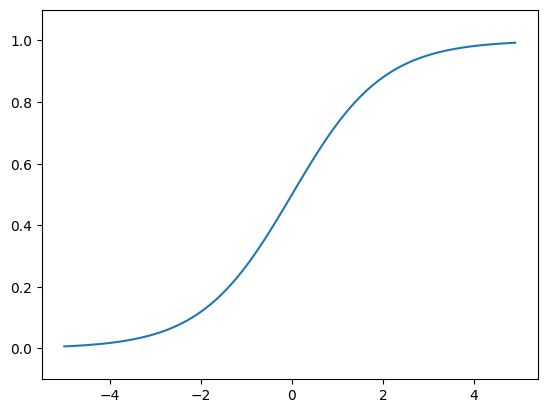

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
#브로드캐스팅이 자동으로 적용
x = np.arange(-5,5,0.1)
y = sigmoid(x)
plt.plot(x,y)
plt.ylim(-0.1,1.1) #y축의범위지정
plt.show()

In [9]:
def relu(x):
    return np.maximum(0, x)

In [11]:
A = np.array([[1,2], [3,4]])
np.dot(A, A)

array([[ 7, 10],
       [15, 22]])

In [14]:
B = np.array([[1,2,3], [4,5,6]])
np.dot(A, B)


array([[ 9, 12, 15],
       [19, 26, 33]])

In [17]:
C = np.shape([[1],[3]])
np.dot(A,C)

array([ 4, 10])

In [20]:
X = np.array([1,2])
W = np.array([[1,2,3], [4,5,6]])
print(np.dot(X,W))

[ 9 12 15]


가중치 표기 : 도착 뉴런이 먼저 


In [26]:
X = np.array([1.0, 0.5])
W1 = np.array([[0.1, 0.3, 0.5], [0.2,0.4,0.6]])
B1 = np.array([0.1, 0.2, 0.3])

A1 = np.dot(X, W1) + B1

In [33]:
z1 = sigmoid(A1)
print(z1)
W2 = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
B2 = np.array([0.1, 0.2])

z2 = sigmoid(np.dot(z1, W2)+B2)
print(z2)

[0.57444252 0.66818777 0.75026011]
[0.62624937 0.7710107 ]


In [40]:
def identity_actfunc(x):
    return x

W3 = np.array([[0.1, 0.2],[0.3, 0.4]])
B3 = np.array([0.1, 0.2])

Y = identity_actfunc(np.dot(z2, W3) + B3)

In [42]:
print(Y)

[0.39392815 0.63365415]


In [ ]:
def softmax_nonorm(a):
    exp_a = np.exp(a)
    sum_exp_a = np.sum(exp_a)
    return exp_a / sum_exp_a

In [ ]:
a = np.array([1010, 1000, 990])
softmax_nonorm(a)

/var/folders/kw/b2hg_vc50cg4rktl0x3hr8tw0000gn/T/ipykernel_65416/1528662570.py:2: RuntimeWarning: overflow encountered in exp
  exp_a = np.exp(a)
/var/folders/kw/b2hg_vc50cg4rktl0x3hr8tw0000gn/T/ipykernel_65416/1528662570.py:4: RuntimeWarning: invalid value encountered in divide
  return exp_a / sum_exp_a


array([nan, nan, nan])

오버플로우가 생기기 때문에..

In [ ]:
softmax_nonorm(a-np.max(a))

array([9.99954600e-01, 4.53978686e-05, 2.06106005e-09])

In [57]:
def softmax(a): #개선
    c = np.max(a)
    return softmax_nonorm(a-c)

계산 자원을 아끼기 위해 추론 단계에서는 솦맥 생략하기도 한다. 
1. 솦맥은 함수 입출력 전후 대소 관계 변화 없는 단조 증가 함수 
2. 학습 단계에서만 필요한 미분 편하라고 쓰기 때문에

확률, 임계값, 앙상블 시에는 추론 단계더라도 사용해야 한다

출력층의 갯수는 분류 원하는 클래수의 갯수만큼